# Esercitazione software 1 
## Analisi in frequenza di brani musicali


*Autori: Fissolo Emanuele (sXXXXXX), Flora Alessandro (sXXXXXX), Giraudo Giacomo (s321784), Intagliata Francesco (sXXXXXX)*  

### Introduzione
**Inserire testo**

### 1) Operazioni preliminari

In [11]:
#in questo blocco eseguiamo tutte le operazione preliminari necessarie per il funzionamento dei
#blocchi di codice successivi

import numpy as np
from cmath import exp, pi
import matplotlib.pyplot as plt
import tes, soundfile, os

#file_audio = str(os.path.join('input', 'Cornfield Chase.wav'))
file_audio = str(os.path.join('input', 'Queen – Bohemian Rhapsody.wav'))

audio, fs = soundfile.read(file_audio)
audio = np.array(audio[:, 0], dtype=np.float32)

len_finestra = 0.5
N = int(fs*len_finestra)   #finestra da 0.5 secondi

Df = 1/(N*1/fs)
x_axis = [x*Df for x in range(int(-N/2),int(N/2))]

print(f"Estratti {len(audio)} campioni - campionati a {fs/1000:.1f}kHz - durata {len(audio)/fs:.2f} secondi")
print(f"Lavoriamo con finestre da {len_finestra:.1f} secondi - {N} campioni per finestra - risoluzione in frequenza {Df:.2f}Hz")

Estratti 880813 campioni - campionati a 44.1kHz - durata 19.97 secondi
Lavoriamo con finestre da 0.5 secondi - 22050 campioni per finestra - risoluzione in frequenza 2.00Hz


### 2) Implementazioni della DFT

#### Introduzione
**Inserire testo**

#### FFT da libreria Numpy
Iniziamo a calcolare la dft della prima finestra temporale della traccia audio utilizzando l'implementazione della FFT (Fast Fourier Transform) implementata nella libreria Numpy di Python

La frequenza corrispondente alla banda al 99% è 7864.0Hz


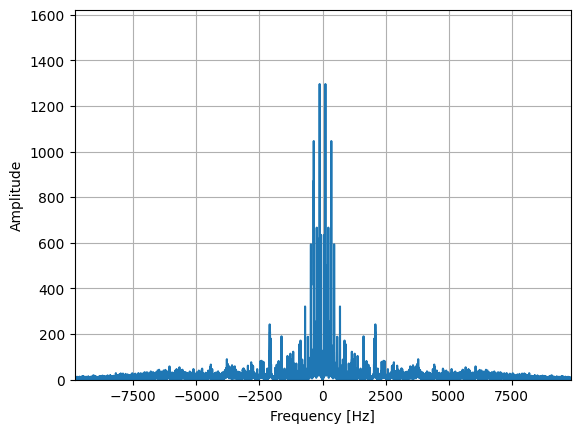

In [12]:
# calcoliamo la FFT sugli N campioni della prima finestra della traccia audio
fft_py = np.abs(np.fft.fft(audio[0:N]))

# calcoliamo il limite di frequenza per avere la banda al 99% del segnale
max_freq_banda = tes.get_limite_banda(tes.get_spettro(fft_py), Df, 99)
print(f"La frequenza corrispondente alla banda al 99% è {max_freq_banda}Hz")

# plottiamo la trasformata
plt.plot(x_axis, np.fft.fftshift(fft_py))
plt.grid(True)
plt.axis([-max_freq_banda*1.25, max_freq_banda*1.25, 0, 1.25 * np.max(fft_py)])
plt.xlabel("Frequency [Hz]")
plt.ylabel("Amplitude")
plt.show()

#### DFT implementata "a mano" in Python
Procediamo ora a implementare l'algoritmo di DFT a partire dalla definzione stessa della Discrete Fourier Transform.
La logica algoritmica è quella vista a lezione per cui si procede a sommare per ogni frequenza le rispettive componenti lungo tutta la finestra temporale del segnale passata in ingresso.

Sempre in Python è stata anche implementata una funzione di **shift** della DFT (di cui è possibile trovarne l'implementazione nel modulo **tes**), utile a ricomporre il risultato della trasformata per ridarle il significato reale.

Nell'esempio di implementazione applicheremo l'algoritmo ad una sotto-finestra temporale di dimensione estremamente ridotta, in quanto il calcolo su una finestra da 0.5 sec richiederebbe svariate decine di minuti

La frequenza corrispondente alla banda al 99% è 3234.0Hz


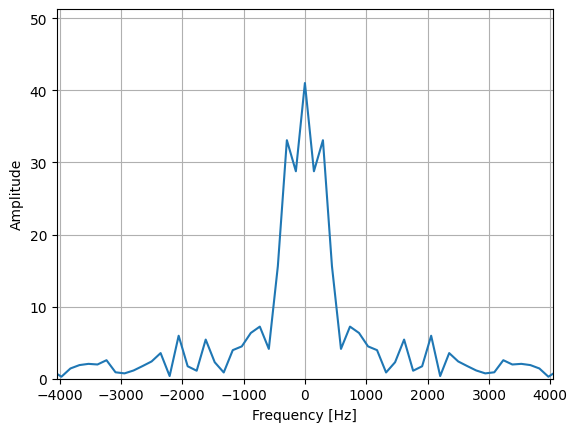

In [3]:
#Implementazione della DFT (su una finestra di dimensioni ridotte)
segnale = audio[0:300]
Nt = len(segnale)
trasformata = [0 for _ in range(Nt)]
for k in range(0, Nt):
    somma = complex(0)

    for n in range(0, Nt):
        somma += segnale[n] * exp(-1j * 2 * pi * n * k/Nt)

    trasformata[k] = somma

dft_py = np.abs(np.array(trasformata))

#calcoliamo la Df e l'asse x per questa finestra temporale troncata
Df_t = 1/(Nt*1/fs)
x_axis_t = [x*Df_t for x in range(int(-Nt/2),int(Nt/2))]

# calcoliamo il limite di frequenza per avere la banda al 99% del segnale
max_freq_banda_t = tes.get_limite_banda(tes.get_spettro(dft_py), Df_t, 99)
print(f"La frequenza corrispondente alla banda al 99% è {max_freq_banda_t}Hz")

# plottiamo lo spettro del segnale
plt.plot(x_axis_t, tes.shift(dft_py))
plt.grid(True)
plt.axis([-max_freq_banda_t*1.25, max_freq_banda_t*1.25, 0, 1.25 * np.max(dft_py)])
plt.xlabel("Frequency [Hz]")
plt.ylabel("Amplitude")
plt.show()

#### DFT implementata "a mano" in C
Spinti dall'inefficienza della soluzione precedente ci siamo chiesti quanto si possa imputare a Python e quanto invece, come esposto a lezione, fosse da imputare all'inefficienza dell'algoritmo.

Abbiamo pertanto, usando **ctypes**, implementato un wrapper in Python che richiama una funzione scritta in C che svolgesse le stesse operazioni della versione in Python.

In [ ]:
# calcoliamo la DFT sugli N campioni della prima finestra della traccia audio
dft_c = tes.dft_c(audio[0:N]) # qui non chiamiamo abs perché viene già calcolato da C

# calcoliamo il limite di frequenza per avere la banda al 99% del segnale
max_freq_banda = tes.get_limite_banda(tes.get_spettro(dft_c), Df, 99)
print(f"La frequenza corrispondente alla banda al 99% è {max_freq_banda}Hz")

# plottiamo lo spettro del segnale
plt.plot(x_axis, tes.shift(dft_c))
plt.grid(True)
plt.axis([-max_freq_banda*1.25, max_freq_banda*1.25, 0, 1.25 * np.max(dft_c)])
plt.xlabel("Frequency [Hz]")
plt.ylabel("Amplitude")
plt.show()

#### Confronto delle prestazioni
**Inserire testo**

### 3) Spettro di energia

**Spiegazione rapida spettro di energia**

#### Preparazione dei file audio

In [19]:
import time
from IPython.display import clear_output
#operazioni preliminari
file_audio1 = str(os.path.join('input', 'Cornfield Chase.wav'))
file_audio2 = str(os.path.join('input', 'Queen – Bohemian Rhapsody.wav'))

audio1, fs1 = soundfile.read(file_audio1)
audio1 = np.array(audio1[:, 0], dtype=np.float32)
audio2, fs2 = soundfile.read(file_audio2)
audio2 = np.array(audio2[:, 0], dtype=np.float32)

len_finestra = 0.5
N1 = int(fs1*len_finestra)
N2 = int(fs2*len_finestra)

Df1 = 1/(N1*1/fs1)
Df2 = 1/(N2*1/fs2)
x_axis1 = [x*Df1 for x in range(int(-N1/2),int(N1/2))]
x_axis2 = [x*Df2 for x in range(int(-N2/2),int(N2/2))]

#### Calcolo spettro di energia su tutte le finestre

##### Prima traccia

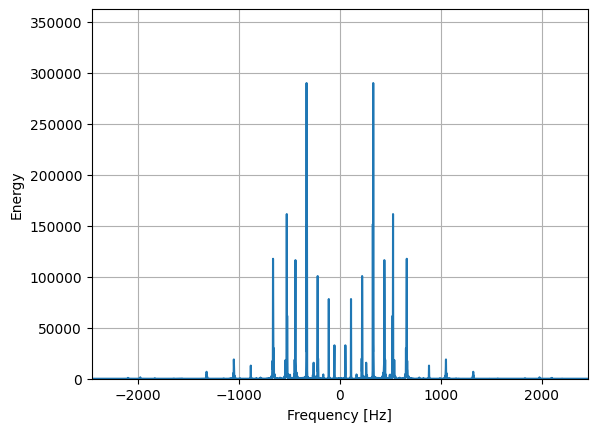

KeyboardInterrupt: 

In [31]:
for i in range(0,int(len(audio1)/N1)):
    clear_output(wait=True)

    energy_spectrum1 = np.power(np.abs(np.fft.fft(audio1[i*N1:i*N1 + N1])), 2)
    max_freq_banda1 = max(tes.get_limite_banda(energy_spectrum1, Df1, 99), max_freq_banda1)

    plt.plot(x_axis1, tes.shift(energy_spectrum1))
    plt.grid(True)
    plt.axis([-max_freq_banda1*1.25, max_freq_banda1*1.25, 0, 1.25 * np.max(energy_spectrum1)])
    plt.xlabel("Frequency [Hz]")
    plt.ylabel("Energy")
    plt.show()
    time.sleep(len_finestra)

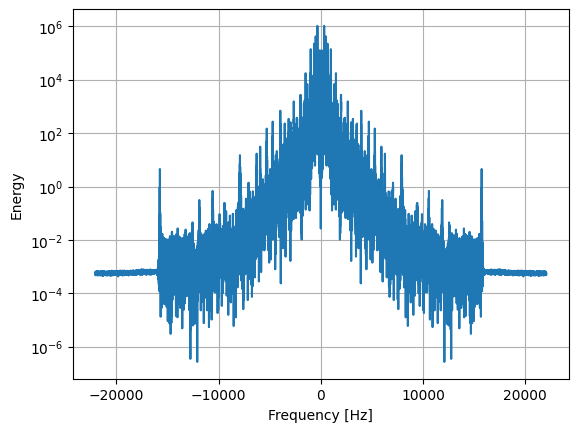

In [33]:
for i in range(0,int(len(audio1)/N1)):
    clear_output(wait=True)

    energy_spectrum1 = np.power(np.abs(np.fft.fft(audio1[i*N1:i*N1 + N1])), 2)
    max_freq_banda1 = max(tes.get_limite_banda(energy_spectrum1, Df1, 99), max_freq_banda1)

    plt.plot(x_axis1, tes.shift(energy_spectrum1))
    plt.grid(True)
    #plt.axis([-max_freq_banda1*1.25, max_freq_banda1*1.25, 0, 1.25 * np.max(energy_spectrum1)])
    plt.xlabel("Frequency [Hz]")
    plt.ylabel("Energy")
    plt.yscale('log')
    plt.show()
    time.sleep(len_finestra)